# Skin Lesion Classifier — Results & Error Analysis

Analytical companion to [`01_eda.ipynb`](01_eda.ipynb). Where the EDA notebook
explored the **data**, this one interrogates the **trained models**: the
accuracy / minority-sensitivity trade-off, per-class behaviour, the confusion
structure, and the single most dangerous error mode — a melanoma called a
benign mole.

**Single source of truth.** Every number here is read from the committed test
metrics in `results/metrics/*_test.json` (9 runs = 3 architectures x 3 losses,
seed 42). Nothing is retrained, so the notebook stays in sync with the README
tables and the live Results dashboard.

> This is a research & educational demonstration. The models are **not** a
> certified medical device — see [`MODEL_CARD.md`](../MODEL_CARD.md) for the
> full scope, data distribution, and limitations.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

# Class order matches src/data/dataset.py CLASSES. In every confusion matrix
# the row is the true label and the column is the prediction.
CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_FULL = {
    "akiec": "Actinic keratoses / Bowen",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevus (benign)",
    "vasc": "Vascular lesion",
}
LOSS_ORDER = ["ce", "wce", "focal"]

METRICS = Path("../results/metrics")
VIZ = Path("../results/visualizations")

records, cms = [], {}
for fp in sorted(METRICS.glob("*_test.json")):
    d = json.loads(fp.read_text(encoding="utf-8"))
    model, loss, _ = d["run_name"].split("-")
    records.append({
        "model": model, "loss": loss,
        "accuracy": d["accuracy"],
        "macro_f1": d["macro_f1"],
        "macro_auc": d["macro_auc"],
        **{f"sens_{c}": d["per_class_sensitivity"][c] for c in CLASSES},
    })
    cms[d["run_name"]] = np.array(d["confusion_matrix"])

df = pd.DataFrame(records)
print(f"Loaded {len(df)} runs: "
      f"{df.model.nunique()} architectures x {df.loss.nunique()} losses (seed 42)")
df[["model", "loss", "accuracy", "macro_f1", "macro_auc"]]

Loaded 9 runs: 3 architectures x 3 losses (seed 42)


,model,loss,accuracy,macro_f1,macro_auc
0,efficientnet_b0,ce,0.806,0.649,0.952
1,efficientnet_b0,focal,0.752,0.635,0.946
2,efficientnet_b0,wce,0.771,0.627,0.945
3,resnet18,ce,0.802,0.612,0.956
4,resnet18,focal,0.730,0.577,0.927
5,resnet18,wce,0.751,0.607,0.941
6,vit_tiny,ce,0.817,0.668,0.960
7,vit_tiny,focal,0.796,0.656,0.951
8,vit_tiny,wce,0.795,0.669,0.960


## 1. The accuracy ↔ minority-sensitivity trade-off

The headline accuracy is dominated by the majority class (nevus is ~61% of the
test set), so it is a poor proxy for clinical usefulness. The question that
matters is whether the model catches the dangerous minority classes —
especially **melanoma**. The three losses span that trade-off: `cross_entropy`
(baseline), `weighted_ce` (inverse-frequency weights), and `focal`
(gamma=2.0, down-weighting easy negatives).

In [2]:
overview = df.pivot_table(index="model", columns="loss",
                          values=["accuracy", "macro_f1", "sens_mel"])
overview = overview.reindex(LOSS_ORDER, axis=1, level=1)
overview

accuracy             macro_f1             sens_mel            
loss                  ce   wce focal       ce   wce focal       ce   wce focal
model                                                                         
efficientnet_b0    0.806 0.771 0.752    0.649 0.627 0.635    0.489 0.602 0.608
resnet18           0.802 0.751 0.730    0.612 0.607 0.577    0.478 0.661 0.677
vit_tiny           0.817 0.795 0.796    0.668 0.669 0.656    0.468 0.591 0.425

In [3]:
# How much accuracy does each reweighting scheme cost, and how much
# melanoma sensitivity does it buy, relative to the cross_entropy baseline?
deltas = []
for model, g in df.groupby("model"):
    base = g[g.loss == "ce"].iloc[0]
    for loss in ["wce", "focal"]:
        r = g[g.loss == loss].iloc[0]
        deltas.append({
            "model": model, "loss": loss,
            "d_accuracy": r.accuracy - base.accuracy,
            "d_sens_mel": r.sens_mel - base.sens_mel,
        })
delta_df = pd.DataFrame(deltas)
delta_df

,model,loss,d_accuracy,d_sens_mel
0,efficientnet_b0,wce,-0.035,0.113
1,efficientnet_b0,focal,-0.054,0.118
2,resnet18,wce,-0.050,0.183
3,resnet18,focal,-0.071,0.199
4,vit_tiny,wce,-0.022,0.124
5,vit_tiny,focal,-0.020,-0.043


For both CNNs the pattern is exactly what class-imbalance theory predicts:
giving up a few points of overall accuracy buys a large jump in melanoma
sensitivity (ResNet18 + focal: **-7pt accuracy, +20pt melanoma recall**).

**The one exception is `vit_tiny` + `focal`** — accuracy drops *and* melanoma
sensitivity falls (-4pt). Focal loss did not regularise ViT-Tiny the way it did
the CNNs here. With a single seed this is a caution flag, not a conclusion, but
it already shows the loss choice **interacts with the architecture** rather than
helping uniformly.

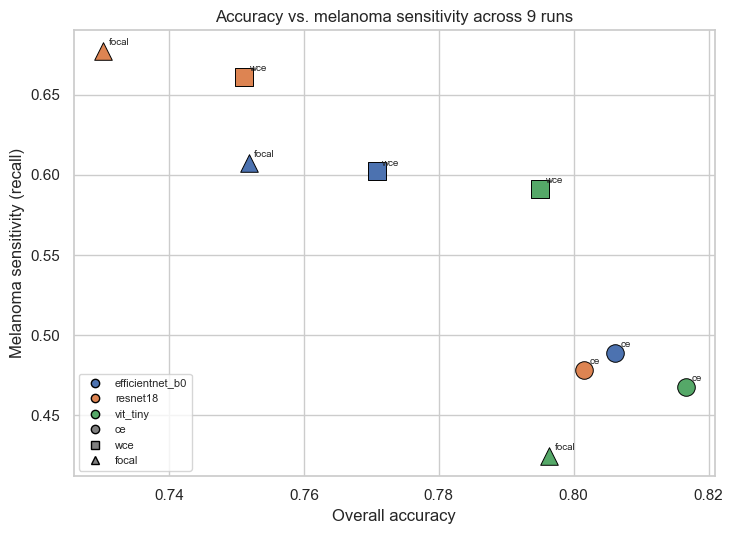

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
markers = {"ce": "o", "wce": "s", "focal": "^"}
palette = dict(zip(sorted(df.model.unique()),
                   sns.color_palette("deep", df.model.nunique())))
for _, r in df.iterrows():
    ax.scatter(r.accuracy, r.sens_mel, s=160, marker=markers[r.loss],
               color=palette[r.model], edgecolor="black", linewidth=0.7)
    ax.annotate(r.loss, (r.accuracy, r.sens_mel), fontsize=7,
                xytext=(4, 4), textcoords="offset points")

model_handles = [plt.Line2D([], [], marker="o", linestyle="", color=c,
                            markeredgecolor="black", label=m)
                 for m, c in palette.items()]
loss_handles = [plt.Line2D([], [], marker=mk, linestyle="", color="grey",
                           markeredgecolor="black", label=loss)
                for loss, mk in markers.items()]
ax.legend(handles=model_handles + loss_handles, fontsize=8, loc="lower left")
ax.set_xlabel("Overall accuracy")
ax.set_ylabel("Melanoma sensitivity (recall)")
ax.set_title("Accuracy vs. melanoma sensitivity across 9 runs")
plt.tight_layout()
plt.show()

## 2. Per-class sensitivity: who benefits from reweighting?

Aggregate accuracy hides which classes move. The heatmap below breaks recall
out per class for all 9 runs.

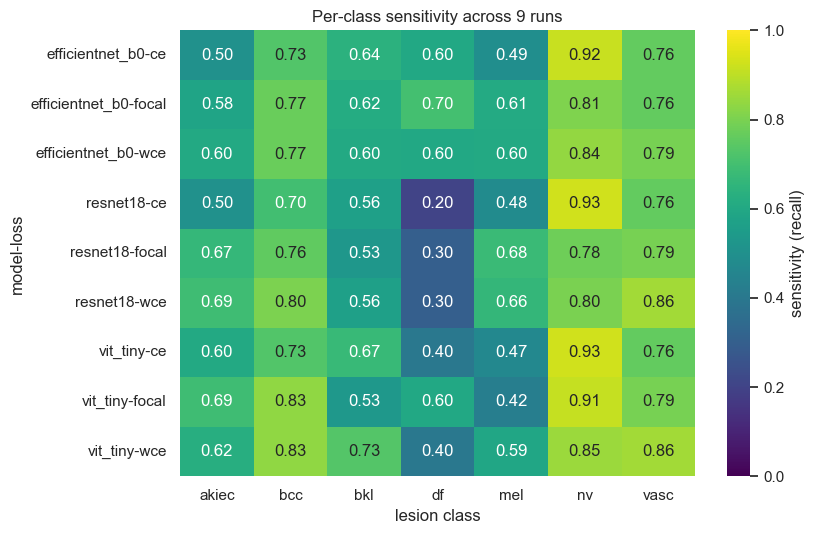

In [5]:
sens = df.set_index(["model", "loss"])[[f"sens_{c}" for c in CLASSES]]
sens.columns = CLASSES
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(sens, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "sensitivity (recall)"}, ax=ax)
ax.set_title("Per-class sensitivity across 9 runs")
ax.set_xlabel("lesion class")
plt.tight_layout()
plt.show()

In [6]:
# The test set is shared across runs, so support is just the confusion-matrix
# row totals. Sensitivity has to be read against these counts.
support = pd.Series(cms["resnet18-ce-seed42"].sum(axis=1), index=CLASSES,
                    name="test_n").sort_values()
support.to_frame().assign(full=[CLASS_FULL[c] for c in support.index])

,test_n,full
df,10,Dermatofibroma
vasc,29,Vascular lesion
akiec,48,Actinic keratoses / Bowen
bcc,66,Basal cell carcinoma
bkl,172,Benign keratosis
mel,186,Melanoma
nv,1016,Melanocytic nevus (benign)


Two things stand out:

- **The majority class is easy and stable.** `nv` stays ~0.93 everywhere; it
  needs no help and is largely unaffected by reweighting.
- **The rare classes are volatile.** `df` has only **10** test images, so its
  recall swings wildly between runs (one or two images flip the number) — read
  it as anecdote, not signal. `akiec`, `vasc`, and `mel` are where the weighted
  and focal losses do their real work, lifting recall at the majority class
  expense.

## 3. Error analysis: the confusion structure

What do the baselines actually confuse? Averaging the row-normalised confusion
matrices over the three `cross_entropy` runs gives the typical error pattern,
independent of any single architecture quirks.

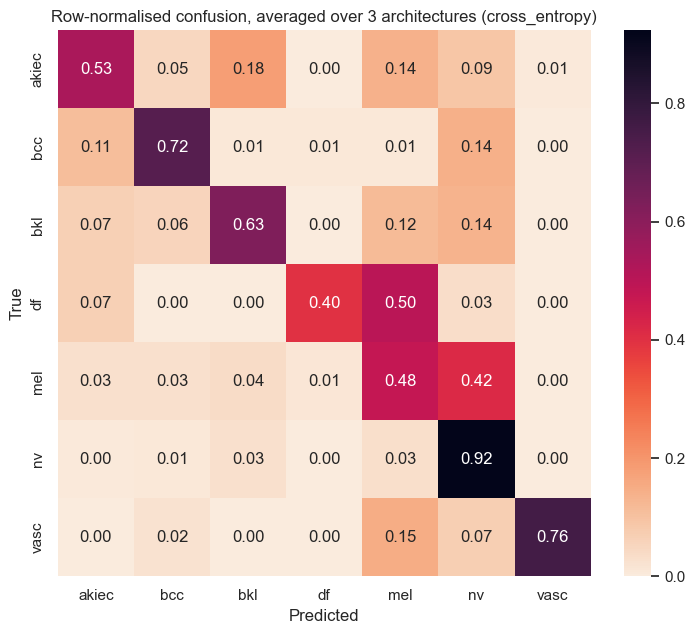

In [7]:
def row_normalize(cm):
    return cm / cm.sum(axis=1, keepdims=True)

avg_ce = np.mean([row_normalize(cms[f"{m}-ce-seed42"])
                  for m in sorted(df.model.unique())], axis=0)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(avg_ce, annot=True, fmt=".2f", cmap="rocket_r",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Row-normalised confusion, averaged over 3 architectures (cross_entropy)")
plt.tight_layout()
plt.show()

In [8]:
# Rank the largest off-diagonal (misclassification) rates.
off = avg_ce.copy()
np.fill_diagonal(off, 0.0)
pairs = [(CLASSES[i], CLASSES[j], off[i, j])
         for i in range(len(CLASSES)) for j in range(len(CLASSES)) if i != j]
top_conf = (pd.DataFrame(pairs, columns=["true", "predicted", "rate"])
            .nlargest(6, "rate").reset_index(drop=True))
top_conf

,true,predicted,rate
0,df,mel,0.500
1,mel,nv,0.416
2,akiec,bkl,0.181
3,vasc,mel,0.149
4,bcc,nv,0.141
5,akiec,mel,0.139


**Nevus is an attractor.** The biggest, most consistent errors collapse
*into* `nv` or `mel`: `mel`->`nv` (~0.42) and `bcc`->`nv` (~0.14) push
malignant lesions toward the benign majority class, while `df`->`mel` (0.50,
but on just 10 images) and `vasc`->`mel` reflect the rare classes having too
few examples to carve out a stable decision boundary. The `mel`->`nv`
collapse is the one with real clinical cost — the next section drills into it.

## 4. The clinically critical failure: melanoma -> nevus

Predicting **benign nevus** for a true **melanoma** is the worst error this
system can make: it would falsely reassure. We track it directly as
P(predicted = nv | true = mel) for every run.

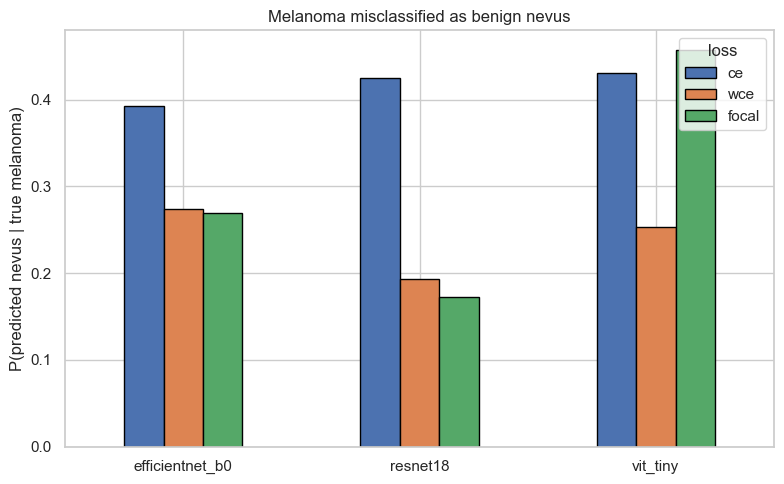

loss,ce,wce,focal
model,,,
efficientnet_b0,0.392,0.274,0.269
resnet18,0.425,0.194,0.172
vit_tiny,0.430,0.253,0.457


In [9]:
mi, ni = CLASSES.index("mel"), CLASSES.index("nv")
mel_nv = []
for name, cm in cms.items():
    model, loss, _ = name.split("-")
    mel_nv.append({"model": model, "loss": loss,
                   "mel_to_nv": cm[mi, ni] / cm[mi].sum()})
mel_nv_pivot = (pd.DataFrame(mel_nv)
                .pivot(index="model", columns="loss", values="mel_to_nv")[LOSS_ORDER])

ax = mel_nv_pivot.plot(kind="bar", figsize=(8, 5), edgecolor="black")
ax.set_ylabel("P(predicted nevus | true melanoma)")
ax.set_xlabel("")
ax.set_title("Melanoma misclassified as benign nevus")
ax.legend(title="loss")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
mel_nv_pivot

The baselines miss melanoma as nevus **~39-43%** of the time. Reweighting
helps the CNNs substantially — ResNet18 + focal cuts it to **0.17**,
EfficientNet to ~0.27. But `vit_tiny` + `focal` goes the *wrong* way (0.43 ->
**0.46**), the same anomaly seen in section 1: for ViT-Tiny here, `weighted_ce`
(0.25) is the safer choice and `focal` actively hurts. The lesson is that the
loss must be validated **per architecture**, not assumed to transfer.

### What is the model looking at?

The Grad-CAM gallery (`scripts/grad_cam_gallery.py`) overlays class-activation
maps for correct and incorrect predictions. The instructive panels are the
**high-confidence melanoma->nevus misses**: the model is not merely
uncertain, it is confidently wrong — exactly the failure mode the model card
warns against. Inspect whether the activation sits on the lesion atypical
structure or drifts onto surrounding skin / artefacts.

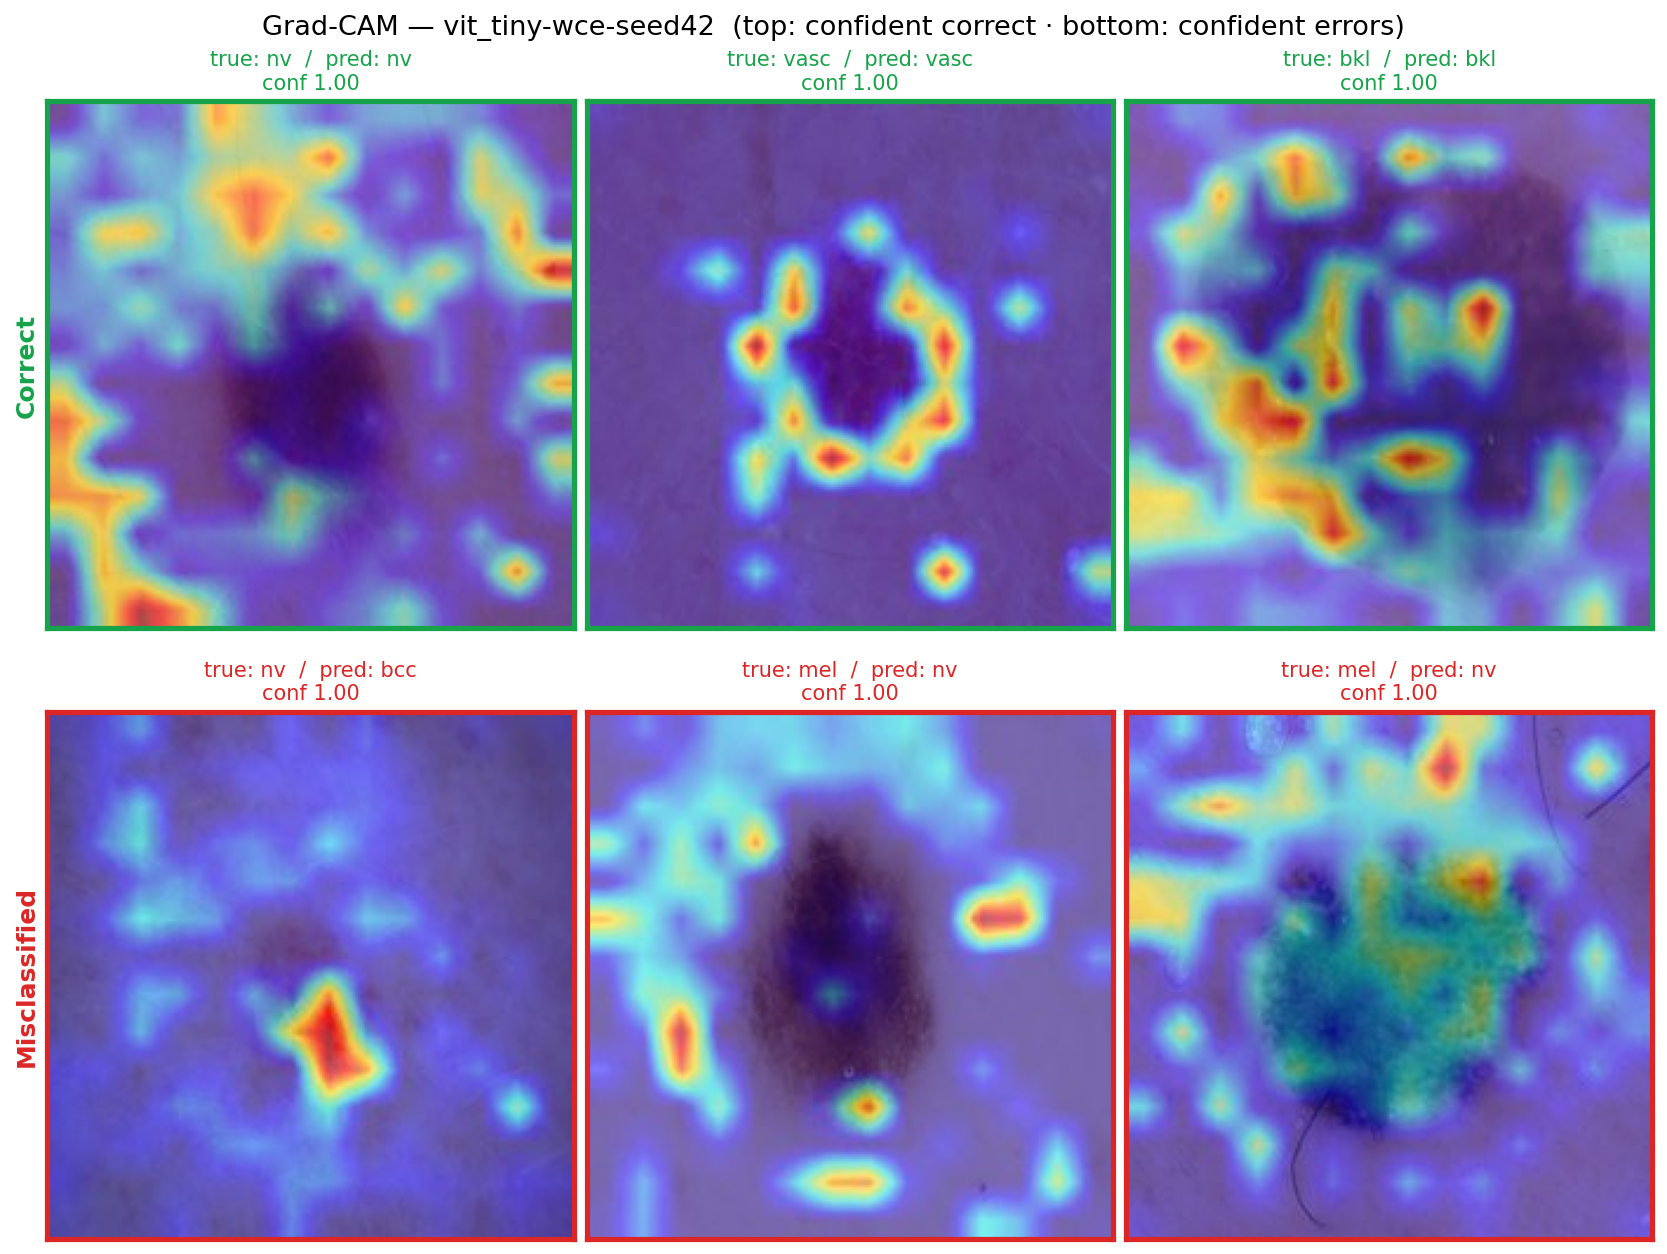

In [10]:
gallery = VIZ / "grad_cam_gallery.png"
display(Image(filename=str(gallery)) if gallery.exists()
        else f"(run scripts/grad_cam_gallery.py to generate {gallery})")

## 5. Cross-architecture synthesis — why ViT-Tiny for the demo?

Averaging each metric over the three losses gives a loss-agnostic ranking of the
architectures.

In [11]:
by_model = (df.groupby("model")[["accuracy", "macro_f1", "macro_auc"]]
            .mean().sort_values("macro_f1", ascending=False))
by_model

,accuracy,macro_f1,macro_auc
model,,,
vit_tiny,0.803,0.664,0.957
efficientnet_b0,0.776,0.637,0.948
resnet18,0.761,0.599,0.941


**ViT-Tiny leads on all three averaged metrics** (macro-F1 and macro-AUC are
the imbalance-aware ones), and per `scripts/profile_models.py` it also has the
lowest CPU inference latency of the three — so it is the default served in the
demo. The caveat from sections 1 and 4 stands: that ranking is the *average*;
the best **loss** for ViT-Tiny is `weighted_ce`, not `focal`.

## 6. Takeaways & limitations

- **The trade-off is real and quantified.** Reweighting trades a few points of
  accuracy for large gains in melanoma recall on the CNNs; accuracy alone is a
  misleading metric under this much class imbalance.
- **`mel`->`nv` is the dominant clinically dangerous error.** Weighted /
  focal losses cut it sharply for ResNet18 and EfficientNet-B0.
- **Loss interacts with architecture.** `focal` helps the CNNs but *hurts*
  ViT-Tiny; `weighted_ce` is the safer default for ViT-Tiny here.
- **Single seed (42).** Magnitudes are indicative, not definitive. Rare classes
  (`df`, n=10) have very wide effective confidence intervals — treat their
  per-run swings as noise.
- **Not a medical device.** See [`MODEL_CARD.md`](../MODEL_CARD.md) for the full
  intended-use scope and limitations.